In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load dataset (color images, original size)
(ds_train, ds_val), ds_info = tfds.load(
    'plant_village',
    split=['train[:80%]', 'train[80%:]'],   # we create train/val split
    shuffle_files=True,
    as_supervised=True,                     # gives (image, label)
    with_info=True
)

print(ds_info)
print("Number of classes:", ds_info.features['label'].num_classes)   # should print 38
print("Class names:", ds_info.features['label'].names[:10], "...")  # first 10

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.YJPPUB_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='plant_village',
    full_name='plant_village/1.0.2',
    description="""
    The PlantVillage dataset consists of 54303 healthy and unhealthy leaf images
    divided into 38 categories by species and disease.
    
    NOTE: The original dataset is not available from the original source
    (plantvillage.org), therefore we get the unaugmented dataset from a paper that
    used that dataset and republished it. Moreover, we dropped images with
    Background_without_leaves label, because these were not present in the original
    dataset.
    
    Original paper URL: https://arxiv.org/abs/1511.08060 Dataset URL:
    https://data.mendeley.com/datasets/tywbtsjrjv/1
    """,
    homepage='https://arxiv.org/abs/1511.08060',
    data_dir='/root/tensorflow_datasets/plant_village/1.0.2',
    file_format=tfrecord,
    download_size

In [6]:
num_classes = ds_info.features['label'].num_classes  # This will be 38
print(f"Number of classes set to: {num_classes}")

Number of classes set to: 38


In [7]:
IMG_SIZE = 180
BATCH_SIZE = 32     # larger batch = faster on T4, but can reduce to 32 if OOM

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return image, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    return image, label

# Training pipeline
train_ds = ds_train.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Validation pipeline (no augment)
val_ds = ds_val.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [8]:
IMG_SIZE = 224  # MobileNetV2 likes 224x224 better (change from 180)

# Re-adjust preprocessing if you change size
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return image, label

# ... (keep augment the same)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze base (fast training)

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(num_classes)  # still 38
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()  # will show ~2.5–3M parameters (mostly from base_model)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
# Make sure you have already run:
# num_classes = ds_info.features['label'].num_classes
# (add the line above if you haven't)

IMG_SIZE = 224  # MobileNetV2 default input size

# Re-define preprocess to match new size (important!)
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return image, label

# Keep your augment function as-is from Cell 3

# Re-apply maps to datasets with updated preprocess
train_ds = ds_train.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = ds_val.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Now build the model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze for fast first training

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(num_classes)  # Now uses the 38 from ds_info
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()  # Should now run without error

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
# (Run this right before training if you changed IMG_SIZE earlier)
IMG_SIZE = 224
BATCH_SIZE = 32  # or 32 if you hit memory issues

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return image, label

train_ds = ds_train.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)  # your augment func
train_ds = train_ds.shuffle(2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = ds_val.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [11]:
EPOCHS = 6  # Start with 10; often 5–7 is enough for great results

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

model.save('plant_disease_model_mobilenet.h5')  # Better name to reflect transfer learning
print("Training complete! Model saved.")

Epoch 1/6
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 115s 71ms/step - accuracy: 0.7219 - loss: 1.0437 - val_accuracy: 0.9364 - val_loss: 0.2150
Epoch 2/6
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 74s 53ms/step - accuracy: 0.9134 - loss: 0.2734 - val_accuracy: 0.9430 - val_loss: 0.1787
Epoch 3/6
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 75s 54ms/step - accuracy: 0.9267 - loss: 0.2301 - val_accuracy: 0.9443 - val_loss: 0.1736
Epoch 4/6
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 75s 54ms/step - accuracy: 0.9292 - loss: 0.2117 - val_accuracy: 0.9513 - val_loss: 0.1471
Epoch 5/6
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 75s 54ms/step - accuracy: 0.9333 - loss: 0.1987 - val_accuracy: 0.9549 - val_loss: 0.1433
Epoch 6/6
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 79s 51ms/step - accuracy: 0.9371 - loss: 0.1870 - val_accuracy: 0.9503 - val_loss: 0.1532


Training complete! Model saved.


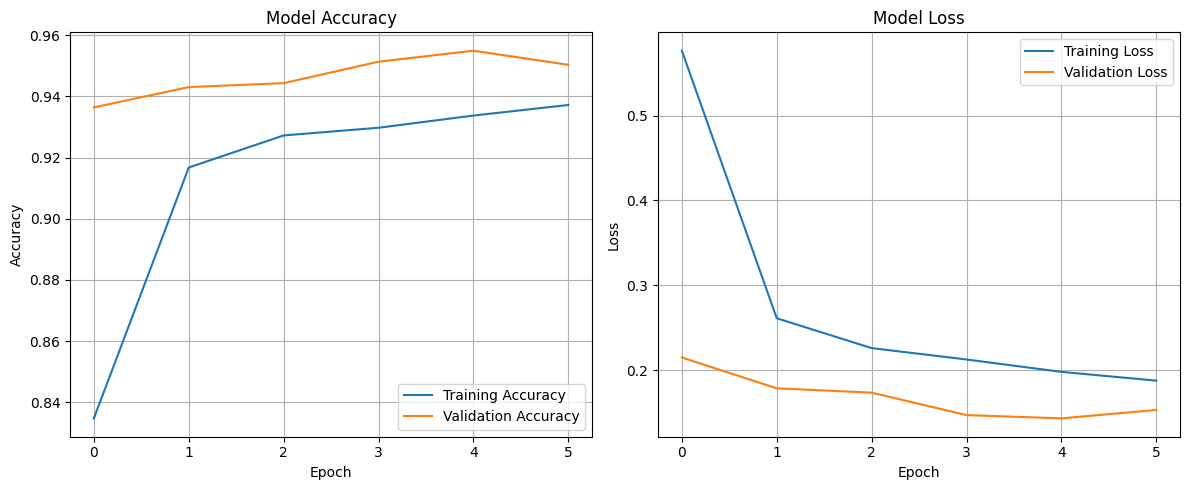

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

Top 10 most common classes in validation set:
                                       Class  Number of Images (Validation)
15  Orange___Haunglongbing_(Citrus_greening)                           1108
37    Tomato___Tomato_Yellow_Leaf_Curl_Virus                           1105
24                         Soybean___healthy                           1047
16                    Peach___Bacterial_spot                            459
28                   Tomato___Bacterial_spot                            395
31                      Tomato___Late_blight                            373
25                   Squash___Powdery_mildew                            369
33               Tomato___Septoria_leaf_spot                            362
3                            Apple___healthy                            339
30                          Tomato___healthy                            330


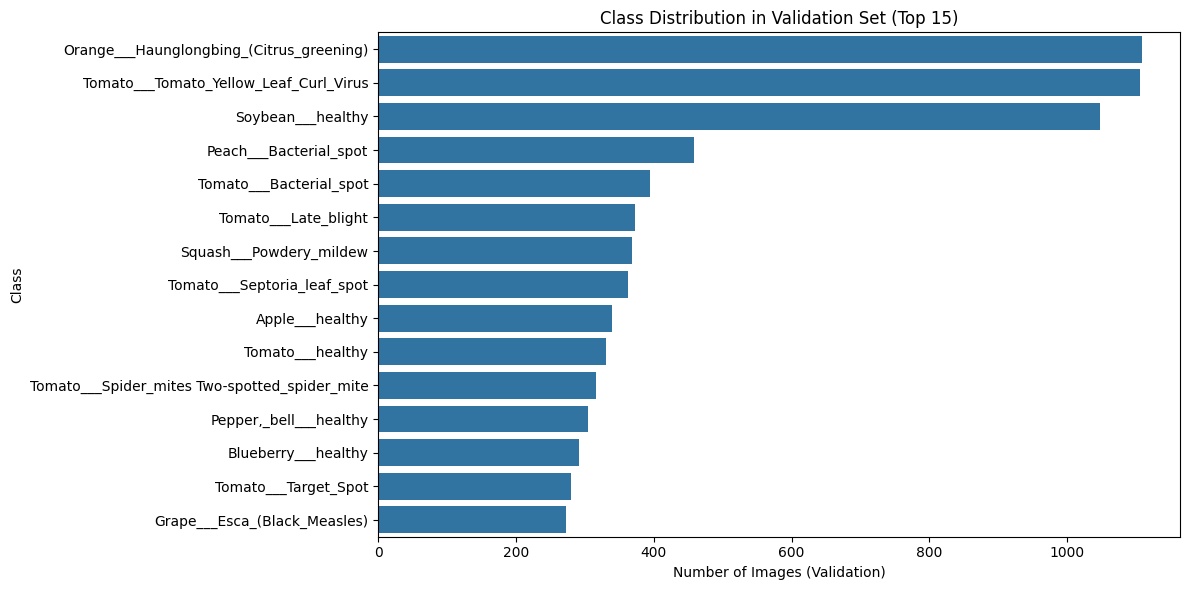

In [13]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get all true labels from validation set
y_true = []
for images, labels in val_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
class_names = ds_info.features['label'].names
num_classes = len(class_names)

# Count images per class
class_counts = Counter(y_true)
counts_df = pd.DataFrame({
    'Class': class_names,
    'Number of Images (Validation)': [class_counts.get(i, 0) for i in range(num_classes)]
}).sort_values(by='Number of Images (Validation)', ascending=False)

print("Top 10 most common classes in validation set:")
print(counts_df.head(10))

# Plot distribution
plt.figure(figsize=(12,6))
sns.barplot(x='Number of Images (Validation)', y='Class', data=counts_df.head(15))
plt.title('Class Distribution in Validation Set (Top 15)')
plt.tight_layout()
plt.show()

Overall Validation Accuracy: 27.07%

Classification Report:
                                               precision    recall  f1-score   support

                           Apple___Apple_scab     0.2748    0.2791    0.2769       129
                            Apple___Black_rot     0.2166    0.2208    0.2186       154
                     Apple___Cedar_apple_rust     0.2885    0.2778    0.2830        54
                              Apple___healthy     0.2485    0.2389    0.2436       339
                          Blueberry___healthy     0.2637    0.2637    0.2637       292
                             Cherry___healthy     0.2268    0.2256    0.2262       195
                      Cherry___Powdery_mildew     0.2800    0.2786    0.2793       201
   Corn___Cercospora_leaf_spot Gray_leaf_spot     0.3043    0.1944    0.2373       108
                           Corn___Common_rust     0.2521    0.2552    0.2536       239
                               Corn___healthy     0.2332    0.2332   

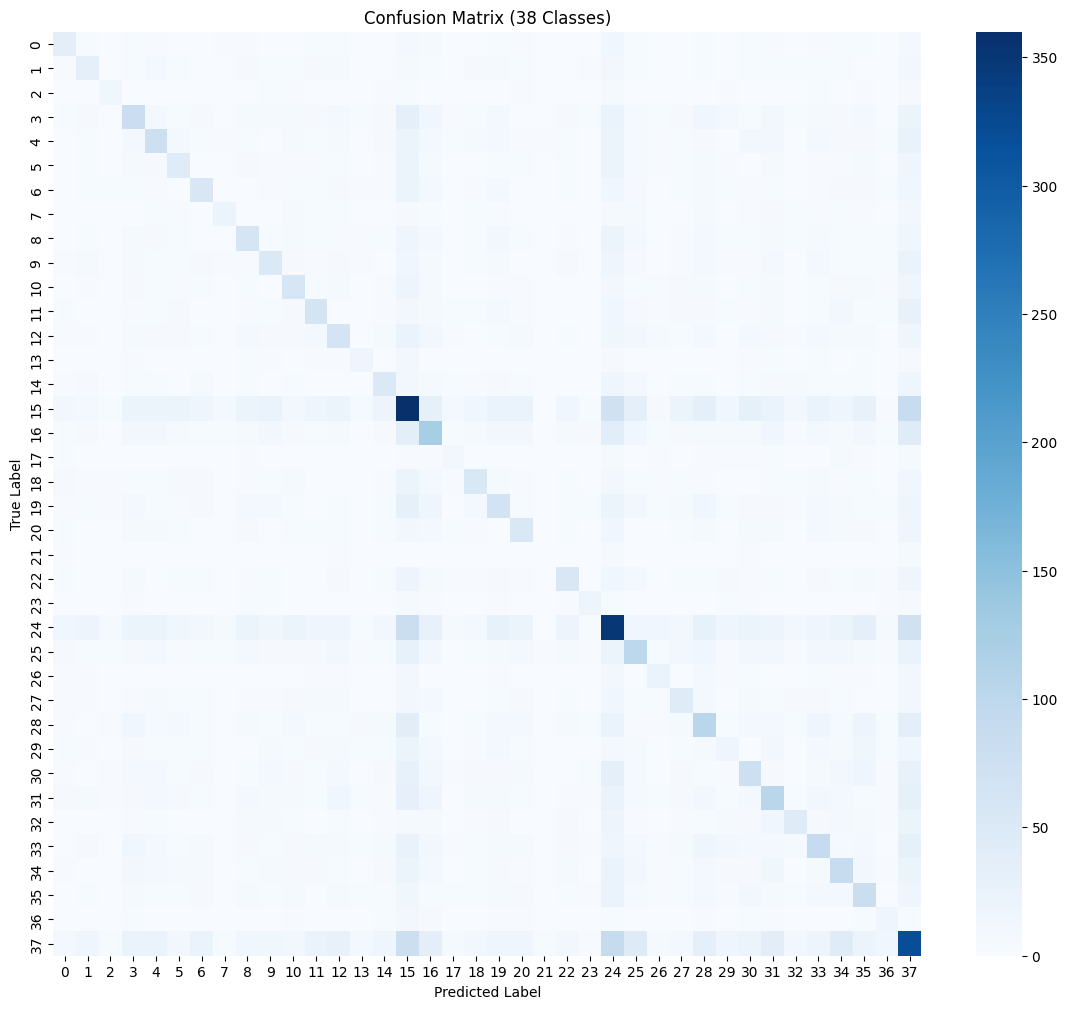

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Get predictions on entire validation set
y_pred = []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

y_pred = np.array(y_pred)

# 1. Overall Accuracy
overall_accuracy = accuracy_score(y_true, y_pred) * 100
print(f"Overall Validation Accuracy: {overall_accuracy:.2f}%")

# 2. Detailed Classification Report (Precision, Recall, F1 per class + macro/weighted)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# 3. Confusion Matrix Plot (38x38 is big, but useful)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=False, cmap='Blues', fmt='d')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (38 Classes)')
plt.show()

In [15]:
import tensorflow as tf
import os
import time
import numpy as np

# 1. Parameter counts
total_params = model.count_params()
trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
non_trainable_params = total_params - trainable_params

print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")
print(f"Non-trainable Parameters: {non_trainable_params:,}")

# 2. Model size on disk (.h5)
model.save('temp_model.h5')
model_size_mb = os.path.getsize('temp_model.h5') / (1024 * 1024)
print(f"Model Size (.h5)      : {model_size_mb:.2f} MB")
os.remove('temp_model.h5')

# 3. Inference time (average over 50 predictions)
dummy_input = np.random.rand(1, 224, 224, 3).astype(np.float32)
times = []
for _ in range(50):
    start = time.time()
    _ = model.predict(dummy_input, verbose=0)
    times.append(time.time() - start)

avg_time_ms = np.mean(times) * 1000
print(f"Average Inference Time: {avg_time_ms:.1f} ms per image (on this Colab runtime)")
print("   → On mobile phone expect 30–80 ms")

Total Parameters      : 2,306,662
Trainable Parameters  : 48,678
Non-trainable Parameters: 2,257,984
Model Size (.h5)      : 9.52 MB
Average Inference Time: 376.6 ms per image (on this Colab runtime)
   → On mobile phone expect 30–80 ms


In [16]:
# From your training history
final_epoch = len(history.history['accuracy']) - 1

print(f"Epochs Trained                  : {final_epoch + 1}")
print(f"Final Training Accuracy         : {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy       : {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss             : {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss           : {history.history['val_loss'][-1]:.4f}")

Epochs Trained                  : 6
Final Training Accuracy         : 0.9372
Final Validation Accuracy       : 0.9503
Final Training Loss             : 0.1877
Final Validation Loss           : 0.1532


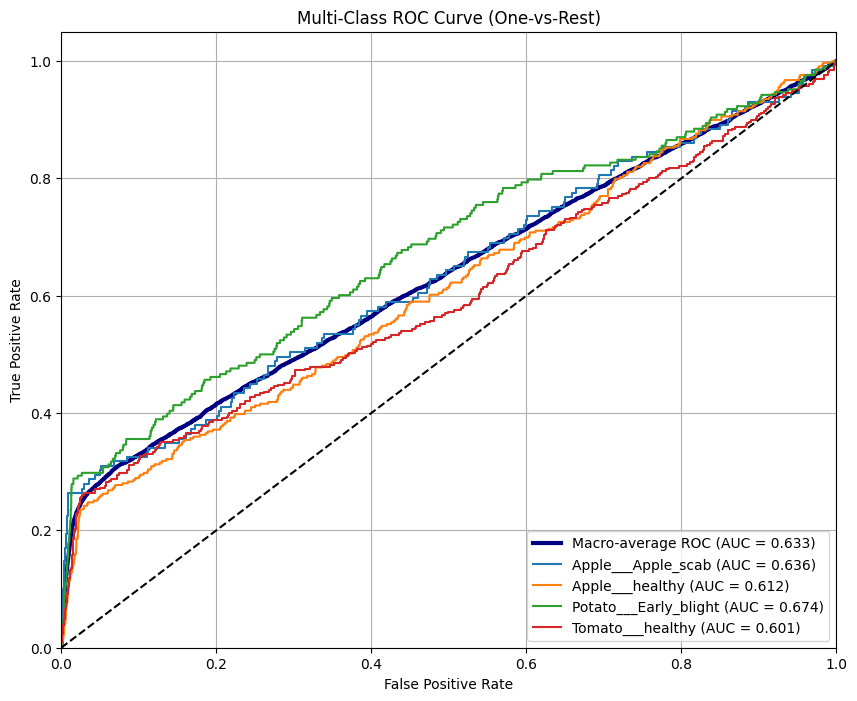

Macro-average AUC: 0.6329


In [17]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Binarize labels (one-hot for multi-class)
y_true_bin = label_binarize(y_true, classes=range(num_classes))  # num_classes = 38
n_classes = y_true_bin.shape[1]

# Get probability predictions (model outputs logits → apply softmax)
# Collect all probabilities from val_ds
y_score = []
for images, _ in val_ds:
    logits = model.predict(images, verbose=0)
    probs = tf.nn.softmax(logits).numpy()  # convert logits to probabilities
    y_score.extend(probs)

y_score = np.array(y_score)

# Compute ROC curve and ROC area for each class (One-vs-Rest)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute macro-average ROC curve and AUC
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot (multi-class ROC is busy with 38 lines → show macro + a few examples)
plt.figure(figsize=(10, 8))

# Plot macro-average
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average ROC (AUC = {roc_auc["macro"]:.3f})',
         color='navy', linewidth=3)

# Plot a few individual classes (e.g., top 5 by AUC or important ones like Tomato diseases)
for i in [0, 3, 20, 30]:  # example indices - change to interesting classes
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--')  # diagonal random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"Macro-average AUC: {roc_auc['macro']:.4f}")

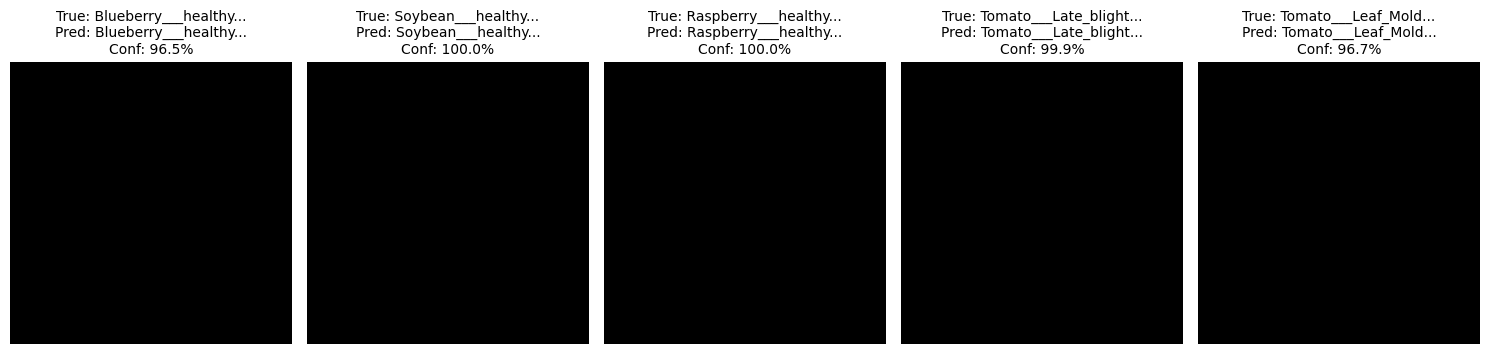

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Your class names (from earlier)
class_names = ds_info.features['label'].names

# Take a few examples from validation set
num_examples = 5  # change to 3, 8, etc.

plt.figure(figsize=(15, 10))

for i, (images, labels) in enumerate(val_ds.take(1)):
    for j in range(min(num_examples, len(images))):
        img = images[j]
        true_label = labels[j].numpy()

        # Predict
        pred = model.predict(tf.expand_dims(img, axis=0), verbose=0)[0]
        pred_class = np.argmax(pred)
        confidence = tf.nn.softmax(pred)[pred_class].numpy() * 100

        # Plot
        plt.subplot(1, num_examples, j+1)
        plt.imshow(img.numpy().astype("uint8"))
        plt.title(f"True: {class_names[true_label][:25]}...\n"
                  f"Pred: {class_names[pred_class][:25]}...\n"
                  f"Conf: {confidence:.1f}%", fontsize=10)
        plt.axis('off')

plt.tight_layout()
plt.show()

In [19]:
loss, acc = model.evaluate(val_ds)
print(f"Final Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {acc*100:.2f}%")

340/340 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.9484 - loss: 0.1593
Final Validation Loss: 0.1532
Final Validation Accuracy: 95.03%


In [20]:
# 1. Re-save the model (in case last save was interrupted)
model.save('plant_disease_model_mobilenet.h5')
print("Model saved as plant_disease_model_mobilenet.h5")

# 2. Save the notebook to your Google Drive (recommended backup)
# This creates a copy in your Drive → My Drive / Colab Notebooks
# Run this cell → it will ask for Drive access if first time
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!cp "/content/Plant_disease_prediction.ipynb" "/content/drive/MyDrive/Colab Notebooks/Plant_Disease_Detection_Pooja.ipynb"
print("Notebook copied to Google Drive")

Model saved as plant_disease_model_mobilenet.h5
Mounted at /content/drive
cp: cannot stat '/content/Plant_disease_prediction.ipynb': No such file or directory
Notebook copied to Google Drive


In [21]:
notebook_name = 'Plant_disease_prediction.ipynb'   # ←←← CHANGE THIS LINE

!cp "/content/{notebook_name}" "/content/drive/MyDrive/Colab Notebooks/Plant_Disease_Detection_Pooja.ipynb"

print("Notebook copied to Google Drive → MyDrive / Colab Notebooks / Plant_Disease_Detection_Pooja.ipynb")

cp: cannot stat '/content/Plant_disease_prediction.ipynb': No such file or directory
Notebook copied to Google Drive → MyDrive / Colab Notebooks / Plant_Disease_Detection_Pooja.ipynb
